### 데이터 무결성 제약조건
1. 도메인 무결성 제약조건
   - 동일한 컬럼은 동일한 자료형만 사용, otherwise Error
2. 개체 무결성 제약조건 (기본키 제약조건)
3. 참조 무결성 제약조건: 1. 부모쪽 테이블에 없는 참조값을 자식테이블이 사용할 수 없다, 2. 자식record가 있는 부모record는 삭제할 수 없다
      - 부모(외래키 없는 테이블), 자식(외래키 있는 테이블). 
      - 자식 테이블이 부모 테이블을 **참조**
      - **FK 설정 시 ON DELETE 옵션 사용**
        - CASCADE -> 부모 레코드 삭제시 자식 레코드 함께 삭제
        - SET NULL -> 부모 레코드 삭제시 자식 레코드의 참조컬럼의 값을 NULL로 교체

### Data Type 자료형
1. 숫자형
    - 정수
        - SMALLINT(2byte)
        - INT(4byte) **0으로 시작 못함**
        - BIGINT(8byte)
   - 실수
     - REAL(4byte)
     - DOUBLE PRECISION(8byte)
     - DECIMAL(p.s)
       - p: 전체 자리수
       - s: 소수점 자리수
2. 문자형
   - CHA(자리수): 고정 사이즈 문자 ex) 남자, 여자
   - VARCHAR(최대 자리수): 최대 자리수만큼의 문자 (최대자리수를 넘지 않으면 문자크기만큼 공간할당)
   - TEXT: 여러줄 텍스트, 길이 제한이 없는 **가변** 문자열

3. 논리형
   - BOOLEAN: True/FALSE/NULL (1byte)

4. 날짜와 시간
   - DATE 날짜만
   - TIME 시간만
   - TIMESTAMP 날짜+시간
   - TIMESTAMPTZ 날짜+시간+시간대(UTC 0 Default)

5. JSON
   - JSONB - binary로 저장 -> 속도 빠름
   - JSON

6. 기타
   - ENUM: 열거형 
        - ex) READY, ORDER, IN_CASH, DELIVERY
        - __ ENUM('READY', 'ORDER', ...)
   - vector(차원수)

[실습]
in MEMBERS TABLE:
- 이름
- 전화번호
- 이메일
- 성별
- 생일
- 주소
- 우편번호
- 가입일

ID - varchar(50)
PASSWORD - varchar(65)

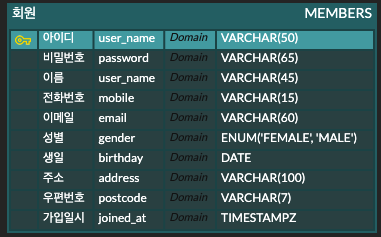

gender -> enum
- enum으로 지정된 값 외에 다른 잘못된 문자열이 들어오는 것을 막음

Primary Key 기본키
- 하나의 레코드를 식별할 수 있는 대표 컬럼 또는 컬럼의 조합
- unique
- not null



---
[0903 수업]
---

### SQL 언어 범주
1. DDL(Data Definition Language): 데이터 정의어
    - CREATE: 대상을 명시하고 시작하는 문법
    - ALTER: 객체 구조 변경
    - DROP: 테이블 삭제
    - TRUNCATE: 테이블 모든 데이터 삭제 (테이블의 구조는 유지)

2. DML(Data Manipulation Language): 데이터 조작어
   - INSERT: 테이블 데이터 추가
   - UPDATE
   - DELETE
   - DQL (Data Query Language) - 데이터 질의어
     - SELECT

3. DCL(Data Control Language): 데이터 제어
   - GRANT
   - REVOKE

4. TCL(Transaction Control Language)
   - COMMIT: 데이터를 DB에 영구반영
   - ROLLBACK: commit 전 반영내용을 되돌림 ex) 주문처리할 때, commit 이후에는 사용 불가

### Transaction의 특성
- 원자성: 한 개 취소하려면 모두 다 취소되어야 함 "All or Nothing"
- 격리성
- 일관성
- 영속성

### 제약조건 (선택, 여러개 사용 가능)
  - 1. PRIMARY KEY: 테이블 내 특정 데이터를 정확히 찾아낼 수 있는 고유 식별자 역할
  - 2. NOT NULL => 빈값이 아니어야 할 때, 컬럼의 필수항목일 때
  - 3. UNIQUE => (not null일 때) 중복 허용 x, NULL은 중복 가능
    - **NULL 역시 허용하지 않는 경우는 NOT NULL과 함께 사용해야 함**
  - 4. CHECK => 특정 조건에 해당하는지 체크

## DDL
```
CREATE table 테이블명(
    컬럼명1 데이터타입 제약조건 DEFAULT ...,
    컬럼명2 데이터타입,
    ...
)
```

```
DROP table 테이블명;
```

- 문장이 끝날때마다 세미콜론;을 붙여 종료를 알림

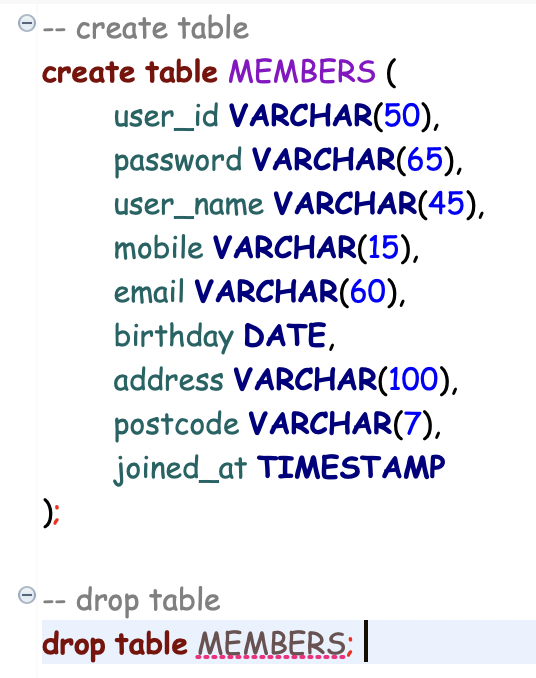

### DML
```
INSERT INTO 테이블명 (컬럼1, 컬럼2, ...) VALUES (v1, v2, ... )
```

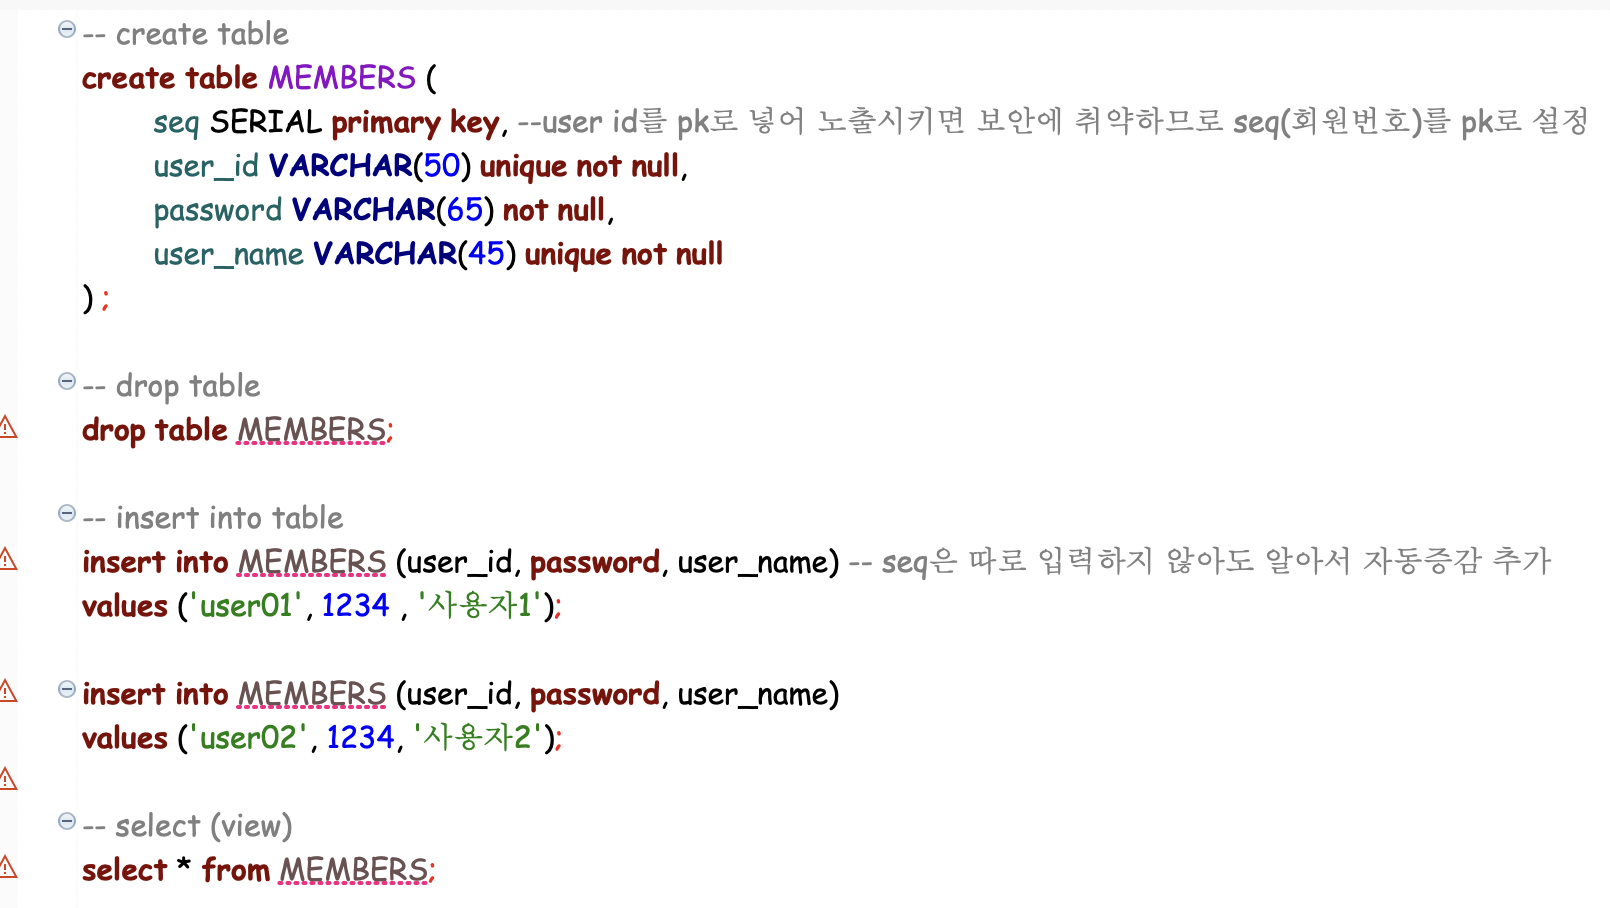

### 자동증감
-> ex) 회원번호 1, 2, 3 붙을 때 자동증감을 이용해 자동으로 숫자 올라가도록 도움
- 표준: `INT GENERATED ALWAYS AS IDENTITY`
- PostgreSQL: 
  - `SERIAL`(4byte)
  - `BIGSERIAL`(8byte)



### 복합키 Composite key
- 여러 컬럼을 조합하여 PK를 구성

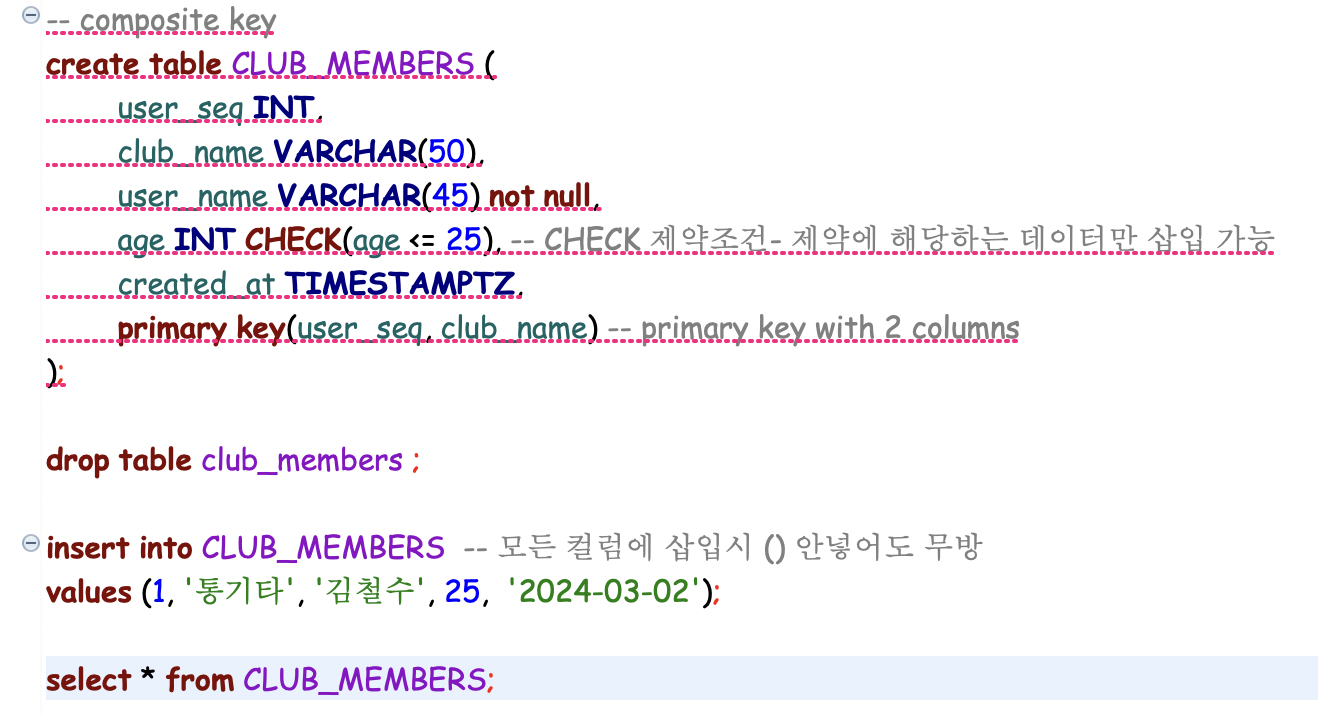

### DEFAULT 기본값 설정 - 선택
ex) 주문상태, 날짜, ...
- 기본값 설정 방법: 내장된 함수 호출, 직접 지정, 내장된 상수 호출, ...
- default CURRENT_TIMESTAMP: 현재 날짜와 시간 설정
- 


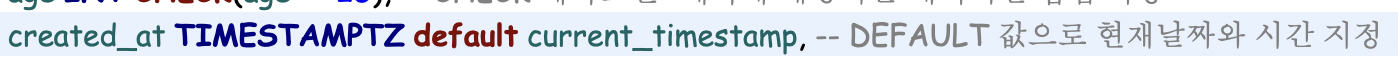

### Foreign Key, Primary Key
- 외래키: 참조 무결성 제약조건 적용

```
CREATE TABLE tablename(
    columnname type condition(s) REFERENCES tablename(columnname)
)
```




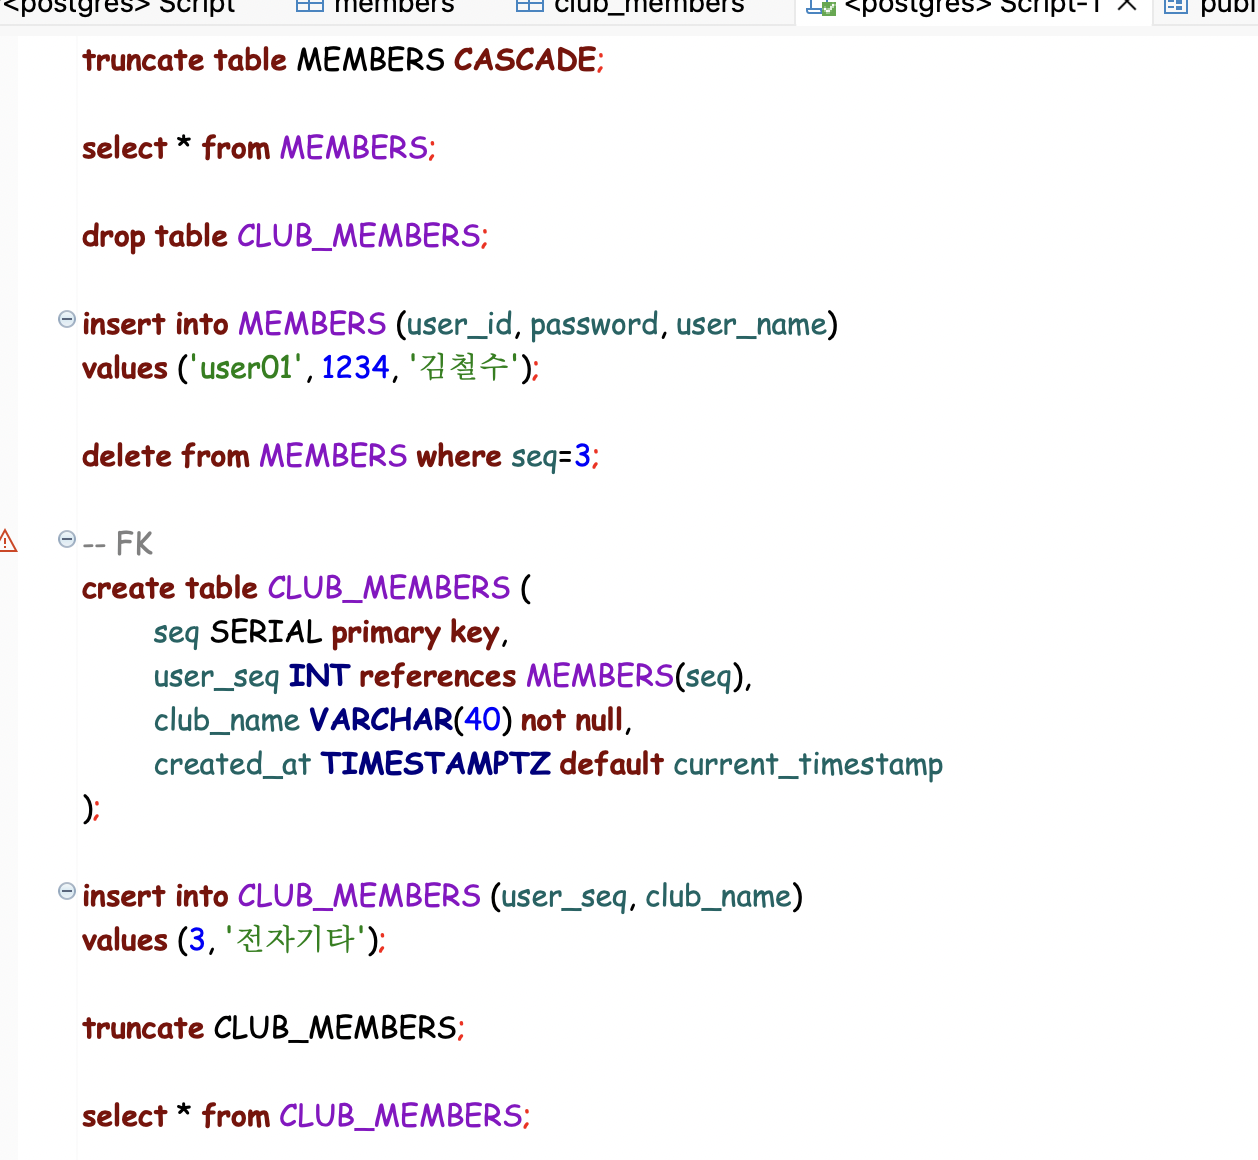

### 데이터베이스 정규화
- 데이터 중복과 이상현상을 개선하기 위해 테이블의 구조를 단계적으로 개선하는 과정
- 테이블을 체계적으로 분리 - 제1정규형, 제2정규형, 제3정규형

### 제1정규형 INF
- 데이터를 원자값으로 분리
- 하나의 컬럼에는 하나의 값만 있어야 한다
- 하나의 컬럼에 여러 값이 들어가면 검색과 수정이 어려움

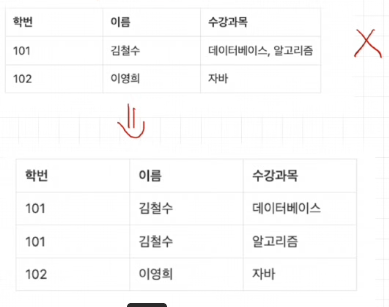

### 제2정규형 2NF
- 하나의 테이블 안에 모든 정보를 넣지 않고, 각 테이블을 분리해서 관리
- 복합기 사용 테이블에서 일부 키에만 의존하는 컬럼을 별도 테이블로 분리함


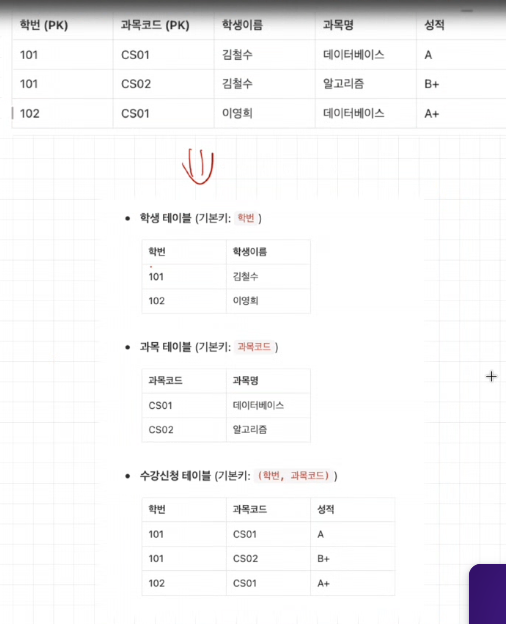

### 제3정규형 3NF
- PK가 아닌 컬럼이 다른 일반 컬럼에 의존하지 않도록 테이블을 분리

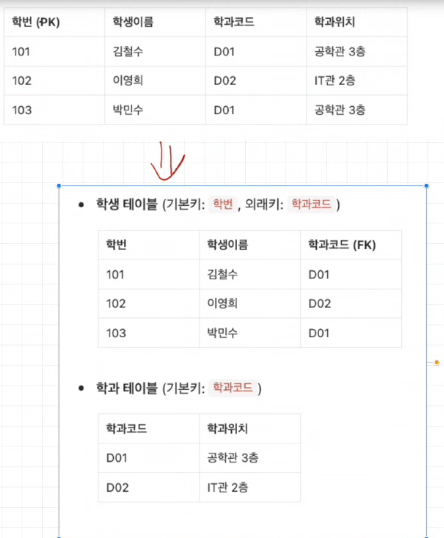